<a href="https://colab.research.google.com/github/strawnsc1/Sam-s-Repository-/blob/main/Lab12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the COVID cases and deaths data
cases_df = pd.read_csv('/content/drive/MyDrive/ia342-lab12/cases (2).csv')

# Load the population income data
income_df = pd.read_csv('/content/drive/MyDrive/ia342-lab12/pop_income (1).csv')

print("Cases Data Head:")
display(cases_df.head())
print("\nCases Data Info:")
cases_df.info()

print("\nIncome Data Head:")
display(income_df.head())
print("\nIncome Data Info:")
income_df.info()

Cases Data Head:


,case_id,confirmed_date,state_name,county_name,confirmed_count,death_count,recovered_count,FIPS
0,1,2020-01-21,WA,Snohomish,1,0,0,53061.0
1,2,2020-01-24,IL,Cook,1,0,0,17031.0
2,3,2020-01-26,AZ,Maricopa,1,0,0,4013.0
3,4,2020-01-26,CA,Los Angeles,1,0,0,6037.0
4,5,2020-01-26,CA,Orange,1,0,0,6059.0



Cases Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095591 entries, 0 to 2095590
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   case_id          int64  
 1   confirmed_date   object 
 2   state_name       object 
 3   county_name      object 
 4   confirmed_count  int64  
 5   death_count      int64  
 6   recovered_count  int64  
 7   FIPS             float64
dtypes: float64(1), int64(4), object(3)
memory usage: 127.9+ MB

Income Data Head:


,B01001_001E,B19013_001E,NAME,state,county
0,21565,46650,"Fayette County, Illinois",17,51
1,29003,57308,"Logan County, Illinois",17,107
2,23994,44090,"Saline County, Illinois",17,165
3,701473,89427,"Lake County, Illinois",17,97
4,14219,47481,"Massac County, Illinois",17,127



Income Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3220 entries, 0 to 3219
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   B01001_001E  3220 non-null   int64 
 1   B19013_001E  3220 non-null   int64 
 2   NAME         3220 non-null   object
 3   state        3220 non-null   int64 
 4   county       3220 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 125.9+ KB


In [2]:
# Filter for Virginia data in cases_df
virginia_cases_df = cases_df[cases_df['state_name'] == 'VA'].copy()

# Clean county names for merging
virginia_cases_df['county_name'] = virginia_cases_df['county_name'].str.replace(' County', '', regex=False).str.strip()
income_df['NAME'] = income_df['NAME'].str.replace(' County, Virginia', '', regex=False).str.strip()

# Merge dataframes
merged_df = pd.merge(virginia_cases_df, income_df, left_on='county_name', right_on='NAME', how='inner')

print("Virginia Cases Data Head:")
display(virginia_cases_df.head())
print("\nMerged Data Head:")
display(merged_df.head())
print("\nMerged Data Info:")
merged_df.info()

Virginia Cases Data Head:


,case_id,confirmed_date,state_name,county_name,confirmed_count,death_count,recovered_count,FIPS
193,194,2020-03-07,VA,Fairfax,1,0,0,51059.0
247,248,2020-03-08,VA,Arlington,1,0,0,51013.0
248,249,2020-03-08,VA,Fairfax,1,0,0,51059.0
300,301,2020-03-09,VA,Fairfax,1,0,0,51059.0
301,302,2020-03-09,VA,Spotsylvania,1,0,0,51177.0



Merged Data Head:


,case_id,confirmed_date,state_name,county_name,confirmed_count,death_count,recovered_count,FIPS,B01001_001E,B19013_001E,NAME,state,county
0,194,2020-03-07,VA,Fairfax,1,0,0,51059.0,1145862,124831,Fairfax,51,59
1,248,2020-03-08,VA,Arlington,1,0,0,51013.0,233464,120071,Arlington,51,13
2,249,2020-03-08,VA,Fairfax,1,0,0,51059.0,1145862,124831,Fairfax,51,59
3,301,2020-03-09,VA,Fairfax,1,0,0,51059.0,1145862,124831,Fairfax,51,59
4,302,2020-03-09,VA,Spotsylvania,1,0,0,51177.0,132833,88628,Spotsylvania,51,177



Merged Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70170 entries, 0 to 70169
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   case_id          70170 non-null  int64  
 1   confirmed_date   70170 non-null  object 
 2   state_name       70170 non-null  object 
 3   county_name      70170 non-null  object 
 4   confirmed_count  70170 non-null  int64  
 5   death_count      70170 non-null  int64  
 6   recovered_count  70170 non-null  int64  
 7   FIPS             70170 non-null  float64
 8   B01001_001E      70170 non-null  int64  
 9   B19013_001E      70170 non-null  int64  
 10  NAME             70170 non-null  object 
 11  state            70170 non-null  int64  
 12  county           70170 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 7.0+ MB


In [3]:
# Convert 'confirmed_date' to datetime objects for time-series analysis
merged_df['confirmed_date'] = pd.to_datetime(merged_df['confirmed_date'])

# Sort by county and date to calculate daily increases
merged_df = merged_df.sort_values(by=['county_name', 'confirmed_date'])

# Calculate daily new confirmed cases and deaths per county
merged_df['daily_confirmed_cases'] = merged_df.groupby('county_name')['confirmed_count'].diff().fillna(0)
merged_df['daily_deaths'] = merged_df.groupby('county_name')['death_count'].diff().fillna(0)

# Ensure no negative daily counts (can happen due to data corrections)
merged_df['daily_confirmed_cases'] = merged_df['daily_confirmed_cases'].apply(lambda x: max(0, x))
merged_df['daily_deaths'] = merged_df['daily_deaths'].apply(lambda x: max(0, x))

# Calculate case and death rates per 100,000 population
# B01001_001E is the total population
merged_df['case_rate_per_100k'] = (merged_df['daily_confirmed_cases'] / merged_df['B01001_001E']) * 100000
merged_df['death_rate_per_100k'] = (merged_df['daily_deaths'] / merged_df['B01001_001E']) * 100000


# Aggregate data by county to get overall statistics and average income
county_summary_df = merged_df.groupby('county_name').agg(
    total_cases=('daily_confirmed_cases', 'sum'),
    total_deaths=('daily_deaths', 'sum'),
    population=('B01001_001E', 'first'), # Population and income are constant per county
    median_income=('B19013_001E', 'first')
).reset_index()

# Calculate overall case and death rates for the entire period per county
county_summary_df['total_case_rate_per_100k'] = (county_summary_df['total_cases'] / county_summary_df['population']) * 100000
county_summary_df['total_death_rate_per_100k'] = (county_summary_df['total_deaths'] / county_summary_df['population']) * 100000

print("County Summary Data Head:")
display(county_summary_df.head())
print("\nCounty Summary Data Info:")
county_summary_df.info()


County Summary Data Head:


,county_name,total_cases,total_deaths,population,median_income,total_case_rate_per_100k,total_death_rate_per_100k
0,Accomack,4325.0,115.0,32673,46073,13237.229517,351.972577
1,Albemarle,10827.0,198.0,107405,79880,10080.536288,184.348960
2,Alleghany,2175.0,104.0,15157,47673,14349.805370,686.151613
3,Amelia,1436.0,61.0,12953,57946,11086.234849,470.933375
4,Amherst,4096.0,102.0,31775,52888,12890.637293,321.007081



County Summary Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county_name                95 non-null     object 
 1   total_cases                95 non-null     float64
 2   total_deaths               95 non-null     float64
 3   population                 95 non-null     int64  
 4   median_income              95 non-null     int64  
 5   total_case_rate_per_100k   95 non-null     float64
 6   total_death_rate_per_100k  95 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 5.3+ KB



--- Analyzing Relationship between Income and COVID-19 Rates ---



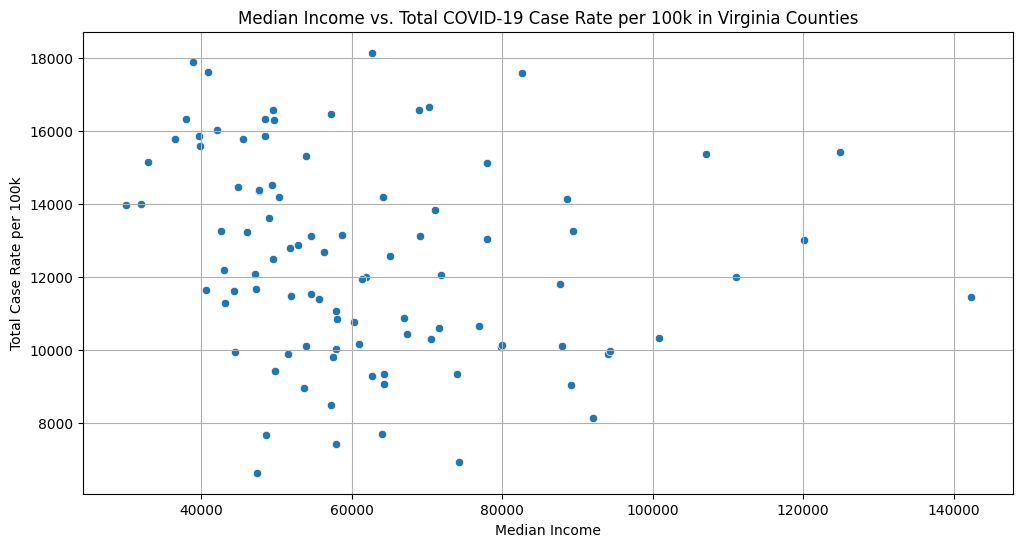

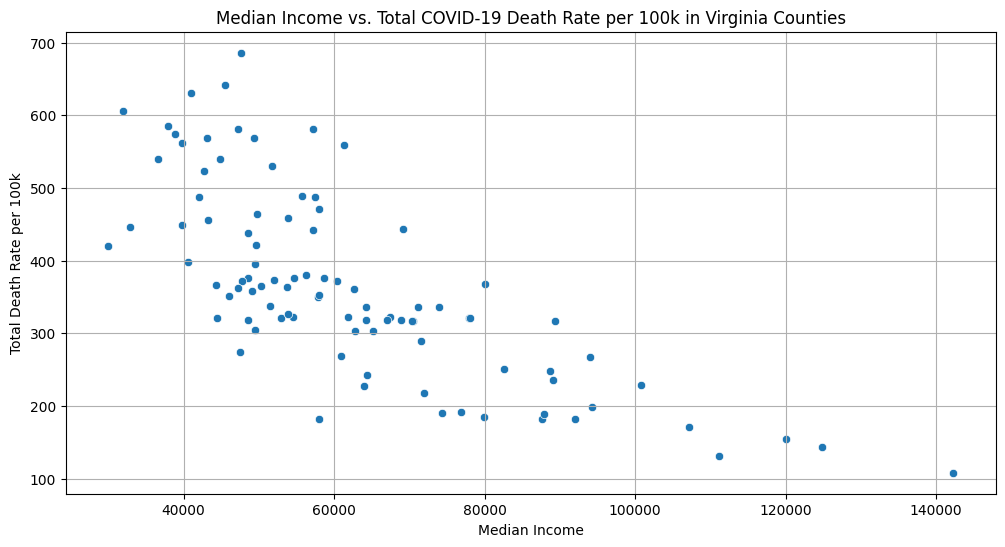

Correlation between Median Income and Total Case Rate: -0.20
Correlation between Median Income and Total Death Rate: -0.74


In [4]:
print("\n--- Analyzing Relationship between Income and COVID-19 Rates ---\n")

# Visualize relationship between median income and total case rate
plt.figure(figsize=(12, 6))
sns.scatterplot(data=county_summary_df, x='median_income', y='total_case_rate_per_100k')
plt.title('Median Income vs. Total COVID-19 Case Rate per 100k in Virginia Counties')
plt.xlabel('Median Income')
plt.ylabel('Total Case Rate per 100k')
plt.grid(True)
plt.show()

# Visualize relationship between median income and total death rate
plt.figure(figsize=(12, 6))
sns.scatterplot(data=county_summary_df, x='median_income', y='total_death_rate_per_100k')
plt.title('Median Income vs. Total COVID-19 Death Rate per 100k in Virginia Counties')
plt.xlabel('Median Income')
plt.ylabel('Total Death Rate per 100k')
plt.grid(True)
plt.show()

# Calculate and print correlation coefficients
case_income_corr = county_summary_df['median_income'].corr(county_summary_df['total_case_rate_per_100k'])
death_income_corr = county_summary_df['median_income'].corr(county_summary_df['total_death_rate_per_100k'])

print(f"Correlation between Median Income and Total Case Rate: {case_income_corr:.2f}")
print(f"Correlation between Median Income and Total Death Rate: {death_income_corr:.2f}")

In [ ]:
# Create a new DataFrame with the requested columns
cleaned_df = county_summary_df[[
    'county_name',
    'total_death_rate_per_100k',
    'total_case_rate_per_100k',
    'population',
    'median_income'
]].copy()

# Add the state name column (since all data is for Virginia)
cleaned_df['state_name'] = 'VA'

# Rename columns for clarity as requested
cleaned_df = cleaned_df.rename(columns={
    'total_death_rate_per_100k': 'death_rate',
    'total_case_rate_per_100k': 'case_rate',
    'median_income': 'income'
})

# Reorder columns to match the request
cleaned_df = cleaned_df[['state_name', 'county_name', 'death_rate', 'case_rate', 'population', 'income']]

print("Cleaned Data Head:")
display(cleaned_df.head())

# Save the cleaned dataset to a CSV file
output_path = '/content/drive/MyDrive/ia342-lab12/virginia_covid_income_analysis.csv'
cleaned_df.to_csv(output_path, index=False)

print(f"\nCleaned data saved to: {output_path}")